# Plots from arXiv:X

### Setup and imports

In [1]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

from ewfs.file_io import load_experiments
from ewfs.ewfs import calculate_branch_factor

DATA_PATH = os.path.join("..", "paper_data")

### Plotting

General functions for rendering the styles of the plots.

In [2]:
def plot_results(
    ax,
    results: dict, 
    friend_sizes: list[int], 
    plot_title: str,
    plot_error_bars: bool = False,
    color: str = "tab:blue",
    label: str | None = None,
    show_legend: bool = False,
    marker: str = "o",
    marker_size: float = 10,
    line_width: float = 2.5,
    y_min: float | None = None,
    y_max: float | None = None,
    optimal_threshold: float = 0.380364,
):
    # Compute averages and standard deviations
    avg_results = {}
    std_results = {}
    for fs in results:
        avg_results[fs] = {}
        std_results[fs] = {}
        for key in results[fs]:
            avg_results[fs][key] = np.mean(results[fs][key])
            if plot_error_bars:
                std_results[fs][key] = np.std(results[fs][key])

    for _, key in enumerate(["semi_brukner"]):
        means = [np.mean(results[fs][key]) for fs in friend_sizes]
        errors = [np.std(results[fs][key]) for fs in friend_sizes] if plot_error_bars else None
        ax.plot(
            friend_sizes,
            means,
            label=label,
            marker=marker,
            markersize=marker_size,
            linestyle="-",
            linewidth=line_width,
            color=color,
        )
        if plot_error_bars:
            ax.errorbar(friend_sizes, means, yerr=errors, fmt="none", color=color, capsize=5, elinewidth=line_width)

    # ax.axhline(optimal_threshold, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
    # ax.axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)

    ax.set_xticks(friend_sizes)
    ax.set_title(plot_title)
    ax.grid(True)

    if y_min is not None and y_max is not None:
        ax.set_ylim(y_min, y_max)    

    if show_legend:
        ax.legend()

In [3]:
def add_branch_factor_axis(ax, friend_sizes, size="large"):
    """Function to create the second x-axis for branch factor at the bottom."""
    ax2 = ax.secondary_xaxis(-0.2)  # Place the second x-axis below the main one
    branch_factors = [calculate_branch_factor(fs) for fs in friend_sizes]
    ax2.set_xticks(friend_sizes)
    ax2.set_xticklabels(branch_factors)
    ax2.set_xlabel("Branch Factor", fontsize=size)
    ax2.tick_params(axis="x", labelsize=size)
    return ax2

## Plots

### Plot: Hardware vs. Fake vs. Simulator

In [4]:
# Load hardware data
osaka_machine_name = "ibm_osaka"
osaka_friend_sizes = range(1, 9)
osaka_num_trials = 10
osaka_shots = 10000
osaka_results = load_experiments(osaka_machine_name, osaka_friend_sizes, osaka_num_trials, osaka_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_ibm_osaka_20240401-232029"))

torino_machine_name = "ibm_torino"
torino_friend_sizes = range(1, 9)
torino_num_trials = 5
torino_shots = 10000
torino_results = load_experiments(torino_machine_name, torino_friend_sizes, torino_num_trials, torino_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_ibm_torino_20240731-113719"))

sherbrooke_machine_name = "ibm_sherbrooke"
sherbrooke_friend_sizes = range(1, 9)
sherbrooke_num_trials = 10
sherbrooke_shots = 10000
sherbrooke_results = load_experiments(sherbrooke_machine_name, sherbrooke_friend_sizes, sherbrooke_num_trials, sherbrooke_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_ibm_sherbrooke_20240402-192806"))

brisbane_machine_name = "ibm_brisbane"
brisbane_friend_sizes = range(1, 9)
brisbane_num_trials = 10
brisbane_shots = 10000
brisbane_results = load_experiments(brisbane_machine_name, brisbane_friend_sizes, brisbane_num_trials, brisbane_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_ibm_brisbane_20240402-161547"))

# Load fake data
fake_kolkata_machine_name = "fake_kolkata"
fake_kolkata_friend_sizes = range(1, 12)
fake_kolkata_num_trials = 10
fake_kolkata_shots = 10000
fake_kolkata_results = load_experiments(fake_kolkata_machine_name, fake_kolkata_friend_sizes, fake_kolkata_num_trials, fake_kolkata_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_fake_kolkata_20240712-121133"))

fake_mumbai_machine_name = "fake_mumbai"
fake_mumbai_friend_sizes = range(1, 12)
fake_mumbai_num_trials = 10
fake_mumbai_shots = 10000
fake_mumbai_results = load_experiments(fake_mumbai_machine_name, fake_mumbai_friend_sizes, fake_mumbai_num_trials, fake_mumbai_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_fake_mumbai_20240713-105519"))

fake_hanoi_machine_name = "fake_hanoi"
fake_hanoi_friend_sizes = range(1, 12)
fake_hanoi_num_trials = 10
fake_hanoi_shots = 10000
fake_hanoi_results = load_experiments(fake_hanoi_machine_name, fake_hanoi_friend_sizes, fake_hanoi_num_trials, fake_hanoi_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_fake_hanoi_20240712-160146"))

fake_cairo_machine_name = "fake_cairo"
fake_cairo_friend_sizes = range(1, 12)
fake_cairo_num_trials = 10
fake_cairo_shots = 10000
fake_cairo_results = load_experiments(fake_cairo_machine_name, fake_cairo_friend_sizes, fake_cairo_num_trials, fake_cairo_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_fake_cairo_20240713-025554"))

# Load simulator data
ideal_sim_name = "ideal_simulator"
ideal_sim_friend_sizes = range(1, 13)
ideal_sim_num_trials = 10
ideal_sim_shots = 10000
ideal_sim_results = load_experiments(ideal_sim_name, ideal_sim_friend_sizes, ideal_sim_num_trials, ideal_sim_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_ideal_simulator_20240712-110233"))

depolarizing_1perc_name = "depolarizing_readout_1perc"
depolarizing_1perc_friend_sizes = range(1, 13)
depolarizing_1perc_num_trials = 10
depolarizing_1perc_shots = 10000
depolarizing_1perc_results = load_experiments(depolarizing_1perc_name, depolarizing_1perc_friend_sizes, depolarizing_1perc_num_trials, depolarizing_1perc_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_depolarizing_readout_1perc_20240826-150058"))

depolarizing_2perc_name = "depolarizing_readout_2perc"
depolarizing_2perc_friend_sizes = range(1, 13)
depolarizing_2perc_num_trials = 10
depolarizing_2perc_shots = 10000
depolarizing_2perc_results = load_experiments(depolarizing_2perc_name, depolarizing_2perc_friend_sizes, depolarizing_2perc_num_trials, depolarizing_2perc_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_depolarizing_readout_2perc_20240826-153359"))

depolarizing_3perc_name = "depolarizing_readout_3perc"
depolarizing_3perc_friend_sizes = range(1, 13)
depolarizing_3perc_num_trials = 10
depolarizing_3perc_shots = 10000
depolarizing_3perc_results = load_experiments(depolarizing_3perc_name, depolarizing_3perc_friend_sizes, depolarizing_3perc_num_trials, depolarizing_3perc_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_depolarizing_readout_3perc_20240826-160717"))

garnet_machine_name = "garnet"
garnet_friend_sizes = range(1, 18)
garnet_num_trials = 5
garnet_shots = 2000
garnet_results = load_experiments(garnet_machine_name, garnet_friend_sizes, garnet_num_trials, garnet_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "garnet_data"))

H1_E_machine_name = "H1-Emulator"
H1_E_friend_sizes = range(1, 11)
H1_E_num_trials = 5
H1_E_shots = 2000
H1_E_results = load_experiments(H1_E_machine_name, H1_E_friend_sizes, H1_E_num_trials, H1_E_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "H1-Emulator_data"))

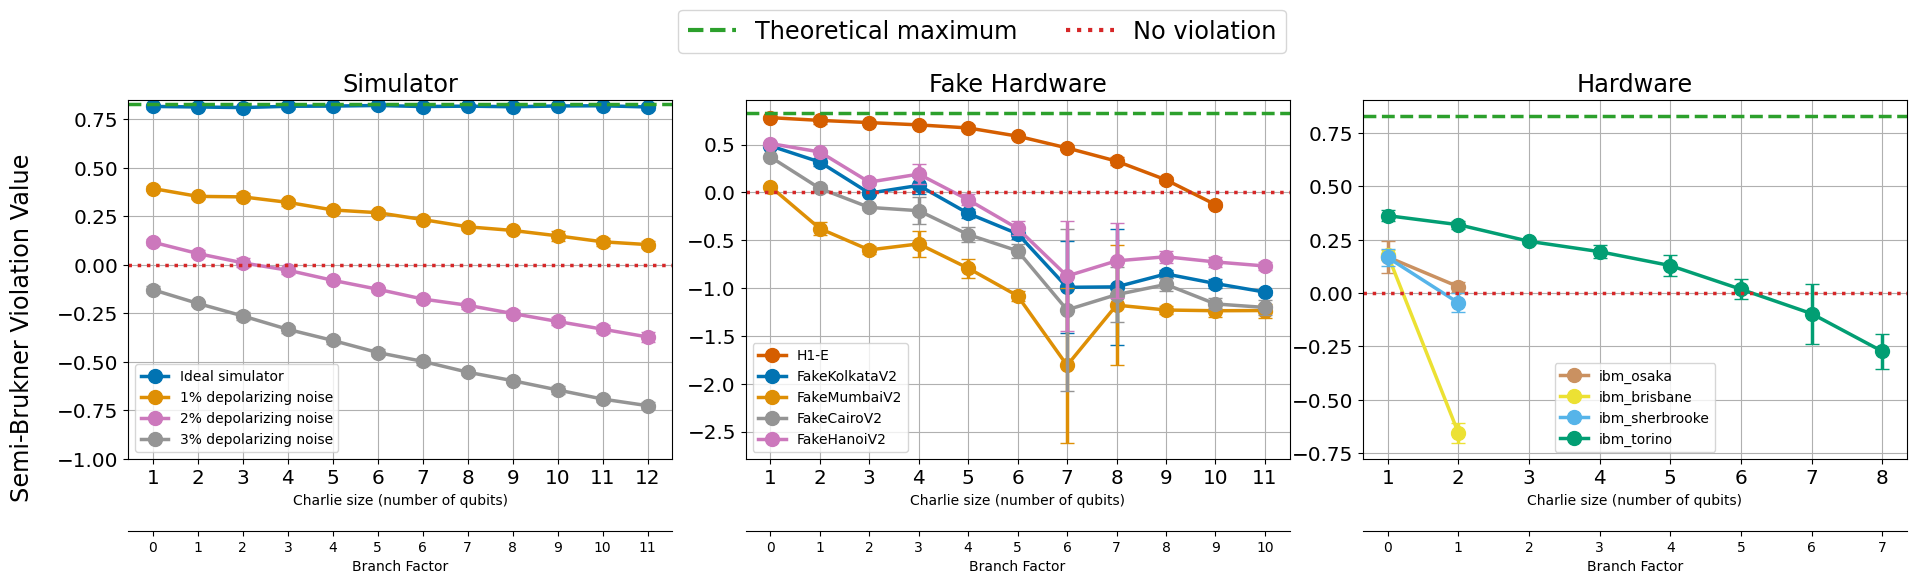

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6))
palette = sns.color_palette("colorblind", n_colors=16)

# Simulator plots
plot_results(axs[0], ideal_sim_results, ideal_sim_friend_sizes, plot_error_bars=True, plot_title="Ideal simulator", color=palette[0], label="Ideal simulator", show_legend=True, y_min=-1, y_max=0.85)
plot_results(axs[0], depolarizing_1perc_results, depolarizing_1perc_friend_sizes, plot_error_bars=True, plot_title="1% depolarizing noise", color=palette[1], label="1% depolarizing noise", show_legend=True)
plot_results(axs[0], depolarizing_2perc_results, depolarizing_1perc_friend_sizes, plot_error_bars=True, plot_title="2% depolarizing noise", color=palette[4], label="2% depolarizing noise", show_legend=True)
plot_results(axs[0], depolarizing_3perc_results, depolarizing_1perc_friend_sizes, plot_error_bars=True, plot_title="3% depolarizing noise", color=palette[7], label="3% depolarizing noise", show_legend=True)

# Fake hardware plots
plot_results(axs[1], H1_E_results, H1_E_friend_sizes, plot_error_bars=True, plot_title="H1-E", color=palette[13], label="H1-E", show_legend=True)
plot_results(axs[1], fake_kolkata_results, fake_kolkata_friend_sizes, plot_error_bars=True, plot_title="Fake Kolkata", color=palette[0], label="FakeKolkataV2", show_legend=True)
plot_results(axs[1], fake_mumbai_results, fake_mumbai_friend_sizes, plot_error_bars=True, plot_title="Fake Mumbai", color=palette[1], label="FakeMumbaiV2", show_legend=True)
plot_results(axs[1], fake_cairo_results, fake_cairo_friend_sizes, plot_error_bars=True, plot_title="Fake Cairo", color=palette[7], label="FakeCairoV2", show_legend=True)
plot_results(axs[1], fake_hanoi_results, fake_hanoi_friend_sizes, plot_error_bars=True, plot_title="Fake Hanoi", color=palette[4], label="FakeHanoiV2", show_legend=True)

# Hardware plots
plot_results(axs[2], osaka_results, osaka_friend_sizes[0:2], plot_error_bars=True, plot_title="ibm_osaka", color=palette[5], label="ibm_osaka", show_legend=True)
plot_results(axs[2], brisbane_results, brisbane_friend_sizes[0:2], plot_error_bars=True, plot_title="ibm_brisbane", color=palette[8], label="ibm_brisbane", show_legend=True)
plot_results(axs[2], sherbrooke_results, sherbrooke_friend_sizes[0:2], plot_error_bars=True, plot_title="ibm_sherbrooke", color=palette[9], label="ibm_sherbrooke", show_legend=True)
plot_results(axs[2], torino_results, torino_friend_sizes, plot_error_bars=True, plot_title="ibm_torino", color=palette[12], label="ibm_torino", show_legend=True)

axs[0].set_title("Simulator", fontsize="xx-large")
axs[1].set_title("Fake Hardware", fontsize="xx-large")
axs[2].set_title("Hardware", fontsize="xx-large")

theoretical_max_handle = mlines.Line2D([], [], color="tab:green", linestyle="dashed", linewidth=3, label="Theoretical maximum")
no_violation_handle = mlines.Line2D([], [], color="tab:red", linestyle="dotted", linewidth=3, label="No violation")

fig.legend([theoretical_max_handle, no_violation_handle], ["Theoretical maximum", "No violation"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

#fig.text(0.5, 0.02, "Charlie Size (Number of qubits)", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Semi-Brukner Violation Value", ha="center", va="center", rotation="vertical", fontsize="xx-large")


axs[0].set_xlabel("Charlie size (number of qubits)")
axs[1].set_xlabel("Charlie size (number of qubits)")
axs[2].set_xlabel("Charlie size (number of qubits)")

# ax2 = axs[0].twiny()
# branch_factors = [calculate_branch_factor(fs) for fs in ideal_sim_friend_sizes]
# ax2.set_xlim(axs[0].get_xlim())
# ax2.set_xticks(ideal_sim_friend_sizes)
# ax2.set_xticklabels(branch_factors)
# ax2.set_xlabel("Branch Factor", fontsize="large")

# ax2 = axs[1].twiny()
# branch_factors = [calculate_branch_factor(fs) for fs in fake_kolkata_friend_sizes]
# ax2.set_xlim(axs[1].get_xlim())
# ax2.set_xticks(fake_kolkata_friend_sizes)
# ax2.set_xticklabels(branch_factors)
# ax2.set_xlabel("Branch Factor", fontsize="large")

# ax2 = axs[2].twiny()
# branch_factors = [calculate_branch_factor(fs) for fs in garnet_friend_sizes]
# ax2.set_xlim(axs[2].get_xlim())
# ax2.set_xticks(garnet_friend_sizes)
# ax2.set_xticklabels(branch_factors)
# ax2.set_xlabel("Branch Factor", fontsize="large")

for ax in np.ravel(axs):
    ax.tick_params(axis="x", labelsize="x-large")
    ax.tick_params(axis="y", labelsize="x-large")    

add_branch_factor_axis(axs[0], ideal_sim_friend_sizes, size="medium")
add_branch_factor_axis(axs[1], fake_kolkata_friend_sizes, size="medium")
add_branch_factor_axis(axs[2], torino_friend_sizes, size="medium")

line_width = 2.5
axs[0].axhline(0.82843, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
axs[0].axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)

axs[1].axhline(0.82843, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
axs[1].axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)

axs[2].axhline(0.82843, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
axs[2].axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.savefig("ghz_majority_vote_simulator_fakehardware_hardware_comparison.pdf", bbox_inches="tight")
plt.show()

### Plot: Majority vote vs. Random on Simulator

In [6]:
# Load simulator data (majority vote)
ideal_sim_name_majority_vote = "ideal_simulator"
ideal_sim_friend_sizes_majority_vote = range(1, 13)
ideal_sim_num_trials_majority_vote = 10
ideal_sim_shots_majority_vote = 10000
ideal_sim_results_majority_vote = load_experiments(ideal_sim_name_majority_vote, ideal_sim_friend_sizes_majority_vote, ideal_sim_num_trials_majority_vote, ideal_sim_shots_majority_vote, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_ideal_simulator_20240712-110233"))

depolarizing_1perc_name_majority_vote = "depolarizing_readout_1perc"
depolarizing_1perc_friend_sizes_majority_vote = range(1, 13)
depolarizing_1perc_num_trials_majority_vote = 10
depolarizing_1perc_shots_majority_vote = 10000
depolarizing_1perc_results_majority_vote = load_experiments(depolarizing_1perc_name_majority_vote, depolarizing_1perc_friend_sizes_majority_vote, depolarizing_1perc_num_trials_majority_vote, depolarizing_1perc_shots_majority_vote, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_depolarizing_readout_1perc_20240826-150058"))

depolarizing_2perc_name_majority_vote = "depolarizing_readout_2perc"
depolarizing_2perc_friend_sizes_majority_vote = range(1, 13)
depolarizing_2perc_num_trials_majority_vote = 10
depolarizing_2perc_shots_majority_vote = 10000
depolarizing_2perc_results_majority_vote = load_experiments(depolarizing_2perc_name_majority_vote, depolarizing_2perc_friend_sizes_majority_vote, depolarizing_2perc_num_trials_majority_vote, depolarizing_2perc_shots_majority_vote, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_depolarizing_readout_2perc_20240826-153359"))

depolarizing_3perc_name_majority_vote = "depolarizing_readout_3perc"
depolarizing_3perc_friend_sizes_majority_vote = range(1, 13)
depolarizing_3perc_num_trials_majority_vote = 10
depolarizing_3perc_shots_majority_vote = 10000
depolarizing_3perc_results_majority_vote = load_experiments(depolarizing_3perc_name_majority_vote, depolarizing_3perc_friend_sizes_majority_vote, depolarizing_3perc_num_trials_majority_vote, depolarizing_3perc_shots_majority_vote, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_depolarizing_readout_3perc_20240826-160717"))

# Load simulator data (random)
ideal_sim_name_random = "ideal_simulator"
ideal_sim_friend_sizes_random = range(1, 13)
ideal_sim_num_trials_random = 10
ideal_sim_shots_random = 10000
ideal_sim_results_random = load_experiments(ideal_sim_name_random, ideal_sim_friend_sizes_random, ideal_sim_num_trials_random, ideal_sim_shots_random, strategy="random", data_path=os.path.join(DATA_PATH, "random_ideal_simulator_20240802-193806"))

depolarizing_1perc_name_random = "depolarizing_readout_1perc"
depolarizing_1perc_friend_sizes_random = range(1, 13)
depolarizing_1perc_num_trials_random = 10
depolarizing_1perc_shots_random = 10000
depolarizing_1perc_results_random = load_experiments(depolarizing_1perc_name_random, depolarizing_1perc_friend_sizes_random, depolarizing_1perc_num_trials_random, depolarizing_1perc_shots_random, strategy="random", data_path=os.path.join(DATA_PATH, "random_depolarizing_readout_1perc_20240826-163938"))

depolarizing_2perc_name_random = "depolarizing_readout_2perc"
depolarizing_2perc_friend_sizes_random = range(1, 13)
depolarizing_2perc_num_trials_random = 10
depolarizing_2perc_shots_random = 10000
depolarizing_2perc_results_random = load_experiments(depolarizing_2perc_name_random, depolarizing_2perc_friend_sizes_random, depolarizing_2perc_num_trials_random, depolarizing_2perc_shots_random, strategy="random", data_path=os.path.join(DATA_PATH, "random_depolarizing_readout_2perc_20240826-165952"))

depolarizing_3perc_name_random = "depolarizing_readout_3perc"
depolarizing_3perc_friend_sizes_random = range(1, 13)
depolarizing_3perc_num_trials_random = 10
depolarizing_3perc_shots_random = 10000
depolarizing_3perc_results_random = load_experiments(depolarizing_3perc_name_random, depolarizing_3perc_friend_sizes_random, depolarizing_3perc_num_trials_random, depolarizing_3perc_shots_random, strategy="random", data_path=os.path.join(DATA_PATH, "random_depolarizing_readout_3perc_20240826-171955"))

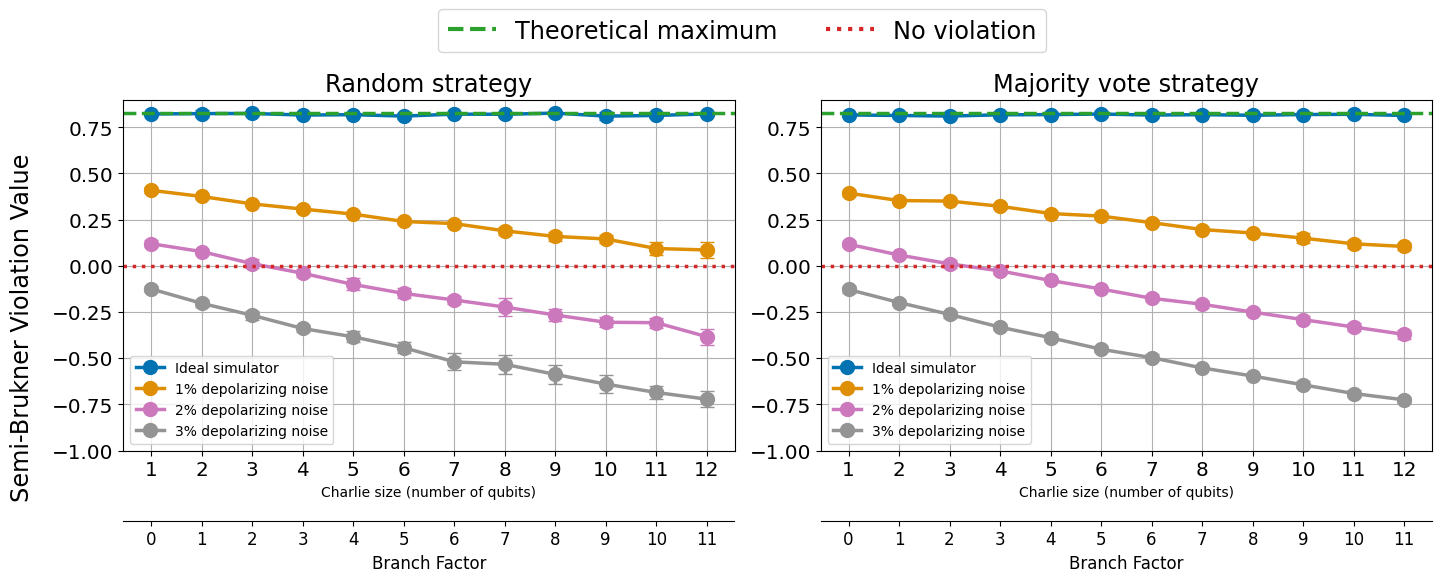

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
palette = sns.color_palette("colorblind", n_colors=8)

# Simulator plots
plot_results(axs[0], ideal_sim_results_random, ideal_sim_friend_sizes_random, plot_error_bars=True, plot_title="Ideal simulator", color=palette[0], label="Ideal simulator", show_legend=True, y_min=-1, y_max=0.9)
plot_results(axs[0], depolarizing_1perc_results_random, depolarizing_1perc_friend_sizes_random, plot_error_bars=True, plot_title="1% depolarizing noise", color=palette[1], label="1% depolarizing noise", show_legend=True)
plot_results(axs[0], depolarizing_2perc_results_random, depolarizing_1perc_friend_sizes_random, plot_error_bars=True, plot_title="2% depolarizing noise", color=palette[4], label="2% depolarizing noise", show_legend=True)
plot_results(axs[0], depolarizing_3perc_results_random, depolarizing_1perc_friend_sizes_random, plot_error_bars=True, plot_title="3% depolarizing noise", color=palette[7], label="3% depolarizing noise", show_legend=True)

plot_results(axs[1], ideal_sim_results_majority_vote, ideal_sim_friend_sizes_majority_vote, plot_error_bars=True, plot_title="Ideal simulator", color=palette[0], label="Ideal simulator", show_legend=True, y_min=-1, y_max=0.9)
plot_results(axs[1], depolarizing_1perc_results_majority_vote, depolarizing_1perc_friend_sizes_majority_vote, plot_error_bars=True, plot_title="1% depolarizing noise", color=palette[1], label="1% depolarizing noise", show_legend=True)
plot_results(axs[1], depolarizing_2perc_results_majority_vote, depolarizing_1perc_friend_sizes_majority_vote, plot_error_bars=True, plot_title="2% depolarizing noise", color=palette[4], label="2% depolarizing noise", show_legend=True)
plot_results(axs[1], depolarizing_3perc_results_majority_vote, depolarizing_1perc_friend_sizes_majority_vote, plot_error_bars=True, plot_title="3% depolarizing noise", color=palette[7], label="3% depolarizing noise", show_legend=True)

axs[0].set_title("Random strategy", fontsize="xx-large")
axs[1].set_title("Majority vote strategy", fontsize="xx-large")

theoretical_max_handle = mlines.Line2D([], [], color="tab:green", linestyle="dashed", linewidth=3, label="Theoretical maximum")
no_violation_handle = mlines.Line2D([], [], color="tab:red", linestyle="dotted", linewidth=3, label="No violation")

fig.legend([theoretical_max_handle, no_violation_handle], ["Theoretical maximum", "No violation"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

#fig.text(0.5, 0.02, "Charlie size (Number of qubits)", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Semi-Brukner Violation Value", ha="center", va="center", rotation="vertical", fontsize="xx-large")

axs[0].set_xlabel("Charlie size (number of qubits)")
axs[1].set_xlabel("Charlie size (number of qubits)")

# ax2 = axs[0].twiny()
# branch_factors = [calculate_branch_factor(fs) for fs in ideal_sim_friend_sizes_random]
# ax2.set_xlim(axs[0].get_xlim())
# ax2.set_xticks(ideal_sim_friend_sizes_random)
# ax2.set_xticklabels(branch_factors)
# ax2.set_xlabel("Branch Factor", fontsize="large")

# ax2 = axs[1].twiny()
# branch_factors = [calculate_branch_factor(fs) for fs in ideal_sim_friend_sizes_majority_vote]
# ax2.set_xlim(axs[1].get_xlim())
# ax2.set_xticks(ideal_sim_friend_sizes_majority_vote)
# ax2.set_xticklabels(branch_factors)
# ax2.set_xlabel("Branch Factor", fontsize="large")

for ax in np.ravel(axs):
    ax.tick_params(axis="x", labelsize="x-large")
    ax.tick_params(axis="y", labelsize="x-large")    

add_branch_factor_axis(axs[0], ideal_sim_friend_sizes_random)
add_branch_factor_axis(axs[1], ideal_sim_friend_sizes_majority_vote)

line_width = 2.5
axs[0].axhline(0.82843, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
axs[0].axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)

axs[1].axhline(0.82843, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
axs[1].axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.savefig("ghz_strategy_simulator_comparison.pdf", bbox_inches="tight")
plt.show()

### Plot: Controlled random unitaries vs. Dicke states

/var/folders/vw/cdx3n5yj7xl3q3g2fv2m676m0000gp/T/ipykernel_88990/495545507.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  random_unitary_ideal = pickle.load(handle)
/var/folders/vw/cdx3n5yj7xl3q3g2fv2m676m0000gp/T/ipykernel_88990/495545507.py:7: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most 

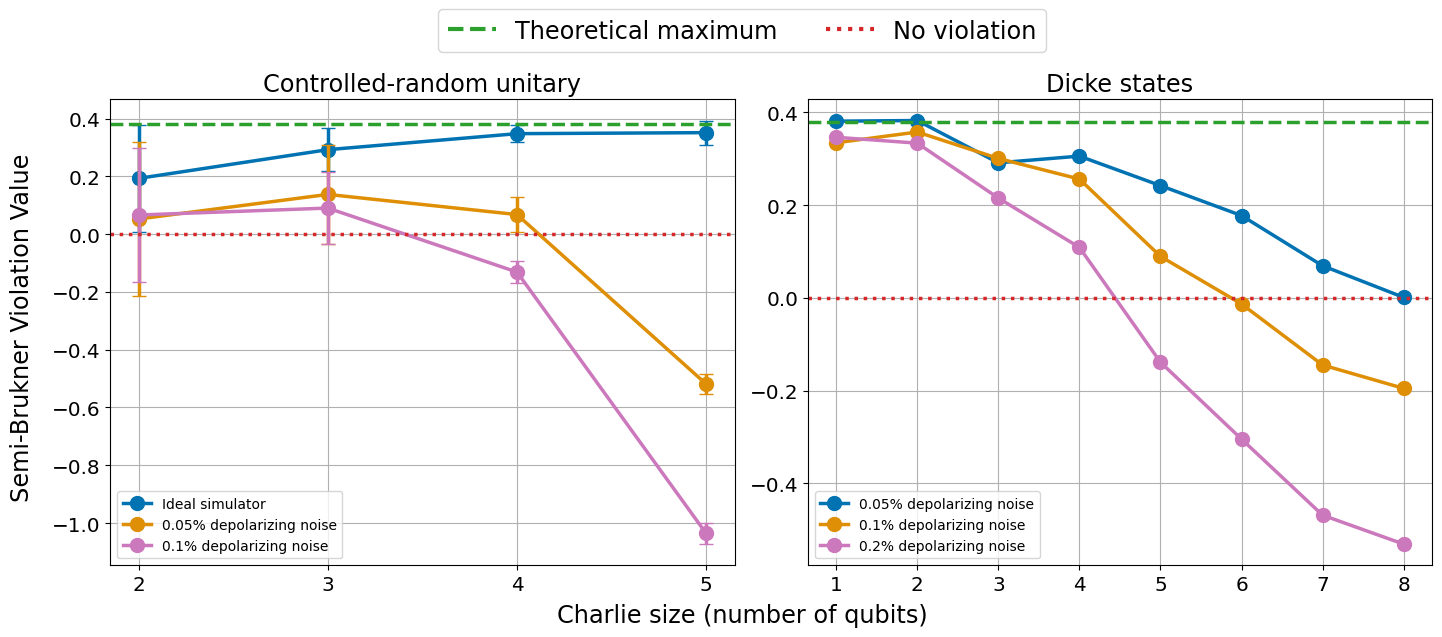

In [8]:
# Read in controlled random unitary data.
random_unitary_friend_sizes = list(range(2, 6))
with open(os.path.join(DATA_PATH, "random_unitary", "random_unitary_res.pkl"), "rb") as handle:
    random_unitary_ideal = pickle.load(handle)

with open(os.path.join(DATA_PATH, "random_unitary", "random_unitary_res_0_005dep.pkl"), "rb") as handle:
    random_unitary_depolarizing_005 = pickle.load(handle)

with open(os.path.join(DATA_PATH, "random_unitary", "random_unitary_res_0_01dep.pkl"), "rb") as handle:
    random_unitary_depolarizing_01 = pickle.load(handle)

# Read in Dicke state data.
dicke_state_friend_sizes = list(range(1, 9))
with open(os.path.join(DATA_PATH, "dicke_states", "dicke_states_res_0_005dep.pkl"), "rb") as handle:
    dicke_states_depolarizing_005 = pickle.load(handle)

with open(os.path.join(DATA_PATH, "dicke_states", "dicke_states_res_0_01dep.pkl"), "rb") as handle:
    dicke_states_depolarizing_01 = pickle.load(handle)

with open(os.path.join(DATA_PATH, "dicke_states", "dicke_states_res_0_02dep.pkl"), "rb") as handle:
    dicke_states_depolarizing_02 = pickle.load(handle)

fig, axs = plt.subplots(1, 2, figsize=(15, 6))
palette = sns.color_palette("colorblind", n_colors=8)

marker="o"
marker_size = 10
linestyle = "-"
line_width = 2.5

axs[0].plot(random_unitary_friend_sizes, np.mean(random_unitary_ideal, axis=0), label="Ideal simulator", marker=marker, markersize=marker_size, color=palette[0], linestyle=linestyle, linewidth=line_width)
axs[0].errorbar(random_unitary_friend_sizes, np.mean(random_unitary_ideal, axis=0), yerr=np.std(random_unitary_ideal, axis=0), fmt="none", capsize=5, color=palette[0], elinewidth=line_width)

axs[0].plot(random_unitary_friend_sizes, np.mean(random_unitary_depolarizing_005, axis=0), label="0.05% depolarizing noise", marker=marker, markersize=marker_size, color=palette[1], linestyle=linestyle, linewidth=line_width)
axs[0].errorbar(random_unitary_friend_sizes, np.mean(random_unitary_depolarizing_005, axis=0), yerr=np.std(random_unitary_depolarizing_005, axis=0), fmt="none", color=palette[1], capsize=5, elinewidth=line_width)

axs[0].plot(random_unitary_friend_sizes, np.mean(random_unitary_depolarizing_01, axis=0), label="0.1% depolarizing noise", marker=marker, markersize=marker_size, color=palette[4], linestyle=linestyle, linewidth=line_width)
axs[0].errorbar(random_unitary_friend_sizes, np.mean(random_unitary_depolarizing_01, axis=0), yerr=np.std(random_unitary_depolarizing_01, axis=0), fmt="none", capsize=5, color=palette[4], elinewidth=line_width)

axs[0].axhline(0.380364, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
axs[0].axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)
axs[0].set_title("Controlled-random unitary", fontsize="xx-large")
axs[0].set_xticks(random_unitary_friend_sizes)
axs[0].grid(True)

axs[1].plot(dicke_state_friend_sizes, dicke_states_depolarizing_005, label="0.05% depolarizing noise", marker=marker, markersize=marker_size, color=palette[0], linestyle=linestyle, linewidth=line_width)
axs[1].plot(dicke_state_friend_sizes, dicke_states_depolarizing_01, label="0.1% depolarizing noise", marker=marker, markersize=marker_size, color=palette[1], linestyle=linestyle, linewidth=line_width)
axs[1].plot(dicke_state_friend_sizes, dicke_states_depolarizing_02, label="0.2% depolarizing noise", marker=marker, markersize=marker_size, color=palette[4], linestyle=linestyle, linewidth=line_width)

axs[1].axhline(0.380364, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
axs[1].axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)
axs[1].set_title("Dicke states", fontsize="xx-large")
axs[1].set_xticks(dicke_state_friend_sizes)
axs[1].grid(True)

theoretical_max_handle = mlines.Line2D([], [], color="tab:green", linestyle="dashed", linewidth=3, label="Theoretical maximum")
no_violation_handle = mlines.Line2D([], [], color="tab:red", linestyle="dotted", linewidth=3, label="No violation")

fig.legend([theoretical_max_handle, no_violation_handle], ["Theoretical maximum", "No violation"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

fig.text(0.5, 0.02, "Charlie size (number of qubits)", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Semi-Brukner Violation Value", ha="center", va="center", rotation="vertical", fontsize="xx-large")

axs[0].legend()
axs[1].legend()

for ax in np.ravel(axs):
    ax.tick_params(axis="x", labelsize="x-large")
    ax.tick_params(axis="y", labelsize="x-large")    

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.savefig("controlled_random_unitary_vs_dicke_state.pdf", bbox_inches="tight")

plt.show()

## Estimated fidelities 

#### Hardware fidelities

In [9]:
# ibm-sherbrooke:
sherbrooke_fids = [0.96565401, 0.9536253 , 0.94447764, 0.93271272, 0.92376566, 0.91490443, 0.90350789, 0.89225331, 0.88113893, 0.87268659, 0.86181594]

# ibm-osaka
osaka_fids = [0.95933409, 0.94511104, 0.93109887, 0.92059762, 0.90694887, 0.89350249, 0.88025546, 0.86720483, 0.85434768, 0.84168116, 0.83218839]

# ibm-torino
torino_fids = [0.98130064, 0.97650567, 0.97173414, 0.96698592, 0.9622609 , 0.95755898, 0.95288002, 0.94822393, 0.94359059, 0.93897989, 0.93439172]
dd = len(torino_fids)

# Quantinuum H1:
h1_fids = [0.99572766, 0.99474599, 0.99376529, 0.99278555, 0.99180677, 0.99082897, 0.98985212, 0.98887624, 0.98790133, 0.98692737, 0.98595437, 0.98498233, 0.98401125, 0.98304113, 0.98207197, 0.98110376]
h1_fids = h1_fids[:len(torino_fids)]
#[0.9413, 0.9317, 0.9221, 0.9098, 0.871 ]

# IonQ Forte:
forte_fids = [0.97684704, 0.97060716, 0.96440714, 0.95824673, 0.95212567, 0.9460437 , 0.94000059, 0.93399608, 0.92802993, 0.92210188, 0.91621171]

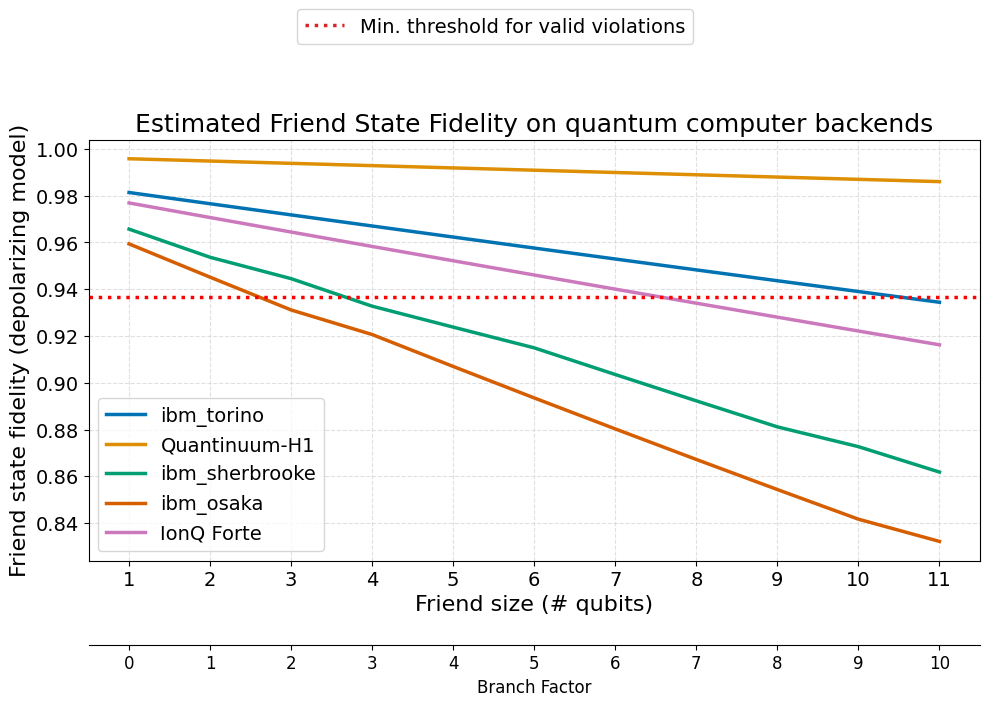

In [10]:
# Set the colorblind palette
colors = sns.color_palette("colorblind")

# Create a plot with adjusted figsize
fig, ax1 = plt.subplots(figsize=(10, 7))

# Plot data on the main x-axis with thicker lines
xs = np.asarray(range(len(h1_fids))) + 1
ax1.plot(xs, torino_fids, label="ibm_torino", color=colors[0], linewidth=2.5)
ax1.plot(xs, h1_fids, label="Quantinuum-H1", color=colors[1], linewidth=2.5)
ax1.plot(xs, sherbrooke_fids, label="ibm_sherbrooke", color=colors[2], linewidth=2.5)
ax1.plot(xs, osaka_fids, label="ibm_osaka", color=colors[3], linewidth=2.5)
ax1.plot(xs, forte_fids, label="IonQ Forte", color=colors[4], linewidth=2.5)

ax1.set_xticks(xs)
ax1.set_xlabel("Friend size (# qubits)", fontsize=16)
ax1.set_ylabel("Friend state fidelity (depolarizing model)", fontsize=16)

# Add grid lines
ax1.grid(True, linestyle='--', alpha=0.7, color='lightgray')
ax1.tick_params(axis='both', which='major', labelsize=14)

plt.legend(loc="lower left", fontsize=14)

# # Create a secondary x-axis at the top
# ax2 = ax1.twiny()

# # Set the secondary x-axis labels
# ax2.set_xlabel("Branch Factor", fontsize=16)
# ax2.set_xticks(xs)
# ax2.set_xticklabels(range(0, dd))

# # Align the secondary x-axis with the main x-axis
# ax1.set_xlim(1, dd)
# ax2.set_xlim(1, dd)
# ax2.set_xbound(ax1.get_xbound())
# ax2.tick_params(axis='x', which='major', labelsize=14)

plt.title("Estimated Friend State Fidelity on quantum computer backends", fontsize=18)

plt.axhline(y=0.9366, color="r", linestyle=":", linewidth=2.5)

no_violation_handle = mlines.Line2D([], [], color="tab:red", linestyle="dotted", linewidth=2.5, label="Min. threshold for valid violations")

fig.legend([no_violation_handle], ["Min. threshold for valid violations"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize=14)

add_branch_factor_axis(ax1, range(1, len(torino_fids) + 1), size="large")

# Adjust the layout
plt.tight_layout()
plt.subplots_adjust(top=0.85)

# Save the figure
plt.savefig("friend_state_fids.pdf", bbox_inches="tight")
plt.show()

#### Hardware 1-qubit and 2-qubit

In [11]:
# ibm-sherbrooke:
sherbrooke_1qs = [46, 65, 72, 91, 98, 105, 124, 143, 162, 169, 188]
sherbrooke_2qs = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

# ibm-osaka
osaka_1qs = [46, 65, 84, 91, 110, 129, 148, 167, 186, 205, 212]
osaka_2qs = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

# ibm-torino
torino_1qs = [31, 37, 43, 49, 55, 61, 67, 73, 79, 85, 91]
torino_2qs = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
dd = len(torino_1qs)

# Quantinuum H1:
h1_1qs = [ 40.,  46.,  52.,  58.,  64.,  70.,  76.,  82.,  88.,  94., 100.,106., 112., 118., 124., 130.]
h1_2qs = [ 4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19.]
h1_1qs = h1_1qs[:dd]
h1_2qs = h1_2qs[:dd]

# IonQ Forte:
forte_1qs = [57, 69, 81, 93, 105, 117, 129, 141, 153, 165, 177]
forte_2qs = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

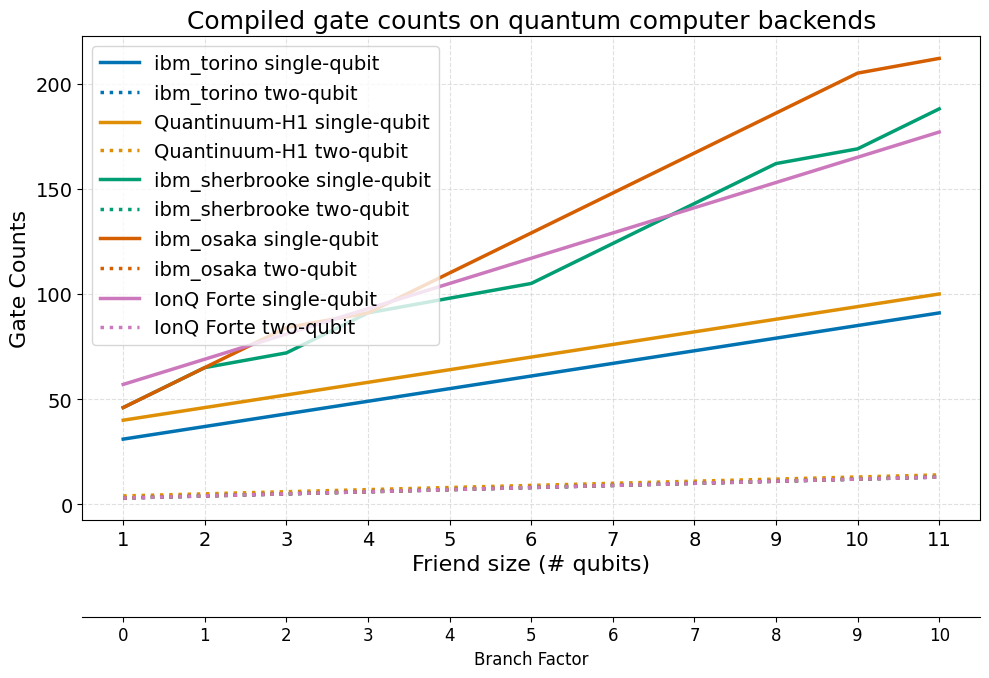

In [12]:
# Set the colorblind palette
colors = sns.color_palette("colorblind")

# Create a plot with adjusted figsize
fig, ax1 = plt.subplots(figsize=(10, 7))

# Plot data on the main x-axis with thicker lines
xs = np.asarray(range(len(torino_2qs))) + 1
ax1.plot(xs, torino_1qs, label="ibm_torino single-qubit", color=colors[0], linewidth=2.5)
ax1.plot(xs, torino_2qs, label="ibm_torino two-qubit", color=colors[0], linestyle=":", linewidth=2.5)
ax1.plot(xs, h1_1qs, label="Quantinuum-H1 single-qubit", color=colors[1], linewidth=2.5)
ax1.plot(xs, h1_2qs, label="Quantinuum-H1 two-qubit", color=colors[1], linestyle=":", linewidth=2.5)
ax1.plot(xs, sherbrooke_1qs, label="ibm_sherbrooke single-qubit", color=colors[2], linewidth=2.5)
ax1.plot(xs, sherbrooke_2qs, label="ibm_sherbrooke two-qubit", color=colors[2], linestyle=":", linewidth=2.5)
ax1.plot(xs, osaka_1qs, label="ibm_osaka single-qubit", color=colors[3], linewidth=2.5)
ax1.plot(xs, osaka_2qs, label="ibm_osaka two-qubit", color=colors[3], linestyle=":", linewidth=2.5)
ax1.plot(xs, forte_1qs, label="IonQ Forte single-qubit", color=colors[4], linewidth=2.5)
ax1.plot(xs, forte_2qs, label="IonQ Forte two-qubit", color=colors[4], linestyle=":", linewidth=2.5)

ax1.set_xticks(xs)
ax1.set_xlabel("Friend size (# qubits)", fontsize=16)
ax1.set_ylabel("Gate Counts", fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=14)

# Add grid lines
ax1.grid(True, linestyle='--', alpha=0.7, color='lightgray')

# # Create a secondary x-axis at the top
# ax2 = ax1.twiny()

# # Set the secondary x-axis labels
# ax2.set_xlabel("Branch Factor", fontsize=16)
# ax2.set_xticks(xs)
# ax2.set_xticklabels(range(0, dd))

# # Align the secondary x-axis with the main x-axis
# ax1.set_xlim(1, dd)
# ax2.set_xlim(1, dd)
# ax2.set_xbound(ax1.get_xbound())
# ax2.tick_params(axis='x', which='major', labelsize=14)

plt.title("Compiled gate counts on quantum computer backends", fontsize=18)

# Add legend in the top left corner with larger font size
ax1.legend(loc="upper left", fontsize=14)

add_branch_factor_axis(ax1, range(1, len(torino_1qs) + 1), size="large")


# Adjust the layout
plt.tight_layout()

# Save the figure
plt.savefig("gate_counts.pdf", bbox_inches="tight")
plt.show()